# **Teori Graf : Penugasan Algoritma Graf Shortest Path dan Minimum Spanning Tree**

### >> **[SOAL NOMOR 1]** Buatlah sebuah matrix ketetanggan graf berbobot dengan 15 node berukuran 15 x 15 (generate menggunakan nilai random), kemudian sajikan pembahasan anda secara mendalam terkait implementasi algoritma shortest path menggunakan :








### **Membuat graf**

- Matriks 15x15 dihasilkan dengan nilai random antara 1 dan 20, dibuat simetris untuk graf undirected, dan diagonal diset ke 0.

- Graf dibangun menggunakan nx.from_numpy_array() dan divisualisasikan dengan layout spring.

Adjacency Matrix (Graf Sparse):
[[ 0  0  0  0  0 19 11  0  0  0  2  0  0  1  0]
 [ 0  0  0  0  0  0 16  0 19  0  0  0  0  0  0]
 [ 0  0  0 14  0  0 20  0  0  0  0 17  0  0  0]
 [ 0  0 14  0  0  0 18  0  0  0  0  0  8  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  7  0  0  0]
 [19  0  0  0  0  0 19  0  0  0  7  0  0  0  0]
 [11 16 20 18  0 19  0  5  0  0  0  0 14  0  0]
 [ 0  0  0  0  0  0  5  0  0  0 15  0 13  0  0]
 [ 0 19  0  0  0  0  0  0  0  0  0  0  7  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  2  0  0]
 [ 2  0  0  0  0  7  0 15  0  0  0 12 11  0  7]
 [ 0  0 17  0  7  0  0  0  0 19 12  0  0  0  0]
 [ 0  0  0  8  0  0 14 13  7  2 11  0  0 13  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  0 13  0  8]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  8  0]]


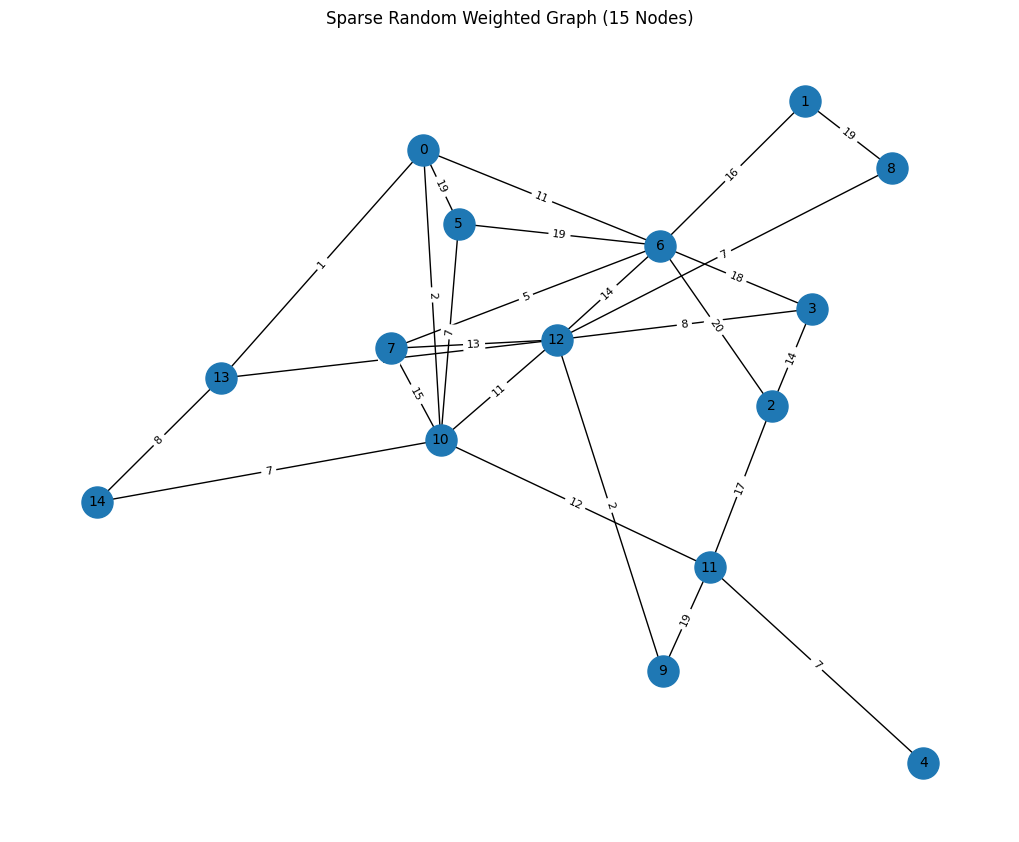

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import heapq
import math

np.random.seed(42)
n = 15  # jumlah vertex
p = 0.2  # probabilitas adanya edge antara dua vertex

# Buat matriks ketetanggaan kosong
A = np.zeros((n, n), dtype=int)

# Isi matriks secara acak: untuk i < j, jika random < p, maka assign bobot random antara 1 dan 20
for i in range(n):
    for j in range(i+1, n):
        if np.random.rand() < p:
            A[i, j] = np.random.randint(1, 21)

# Karena graf tidak berarah, simetriskan matriks
A = A + A.T

# Pastikan diagonal adalah 0 (tidak ada self-loop)
np.fill_diagonal(A, 0)

print("Adjacency Matrix (Graf Sparse):")
print(A)

# Buat graf dari matriks
G = nx.from_numpy_array(A)

# Visualisasi graf
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Sparse Random Weighted Graph (15 Nodes)")
plt.show()

source_node = 0
target_node = 14

def visualize_path(G, pos, path, title):
    plt.figure(figsize=(8,6))
    nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=3, style='dashed', edge_color='r')
    plt.title(title)
    plt.show()

graph_adj = {}
for node in G.nodes():
    graph_adj[node] = [(neighbor, data['weight']) for neighbor, data in G[node].items()]

#### Penjelasan Kode

**Tujuan Kode :**

Membangun dan memvisualisasikan graf berbobot acak yang sparse (jarang terhubung) dengan 15 node menggunakan NetworkX dan matplotlib.

**Penjelasan per bagian :**

- np.random.seed(42)

Untuk memastikan hasil random yang konsisten setiap kali dijalankan (reproducibility).

- n = 15, p = 0.2

Menentukan jumlah node (15) dan probabilitas 20% bahwa dua node akan terhubung dengan edge.

- Membangun matriks ketetanggaan (adjacency matrix) A:

    - Matriks 15x15 diisi dengan:

        - Edge antara node i dan j hanya dibuat jika np.random.rand() < p.

        - Bobot edge ditentukan secara acak antara 1–20.

    - Matriks kemudian disimetriskan agar menjadi graf undirected.

    - Diagonal diisi 0 (tidak ada self-loop).

- nx.from_numpy_array(A)

Mengubah matriks A menjadi graf NetworkX (G).

- Visualisasi Graf:

    Layout posisi node menggunakan spring layout.

    Graf digambar lengkap dengan label node dan label bobot edge.

- source_node = 0, target_node = 14

Menentukan node awal dan akhir untuk pencarian jalur (belum dipakai di bagian ini, tapi akan dipakai nanti).

- visualize_path()

Fungsi untuk memvisualisasikan graf dan menampilkan jalur tertentu dalam warna merah dengan garis putus-putus.

- graph_adj = {}

Membuat representasi adjacency list dari graf, agar bisa digunakan untuk algoritma shortest path seperti Dijkstra, A*, dll.

### **A.)** **DIJKSTRA'S ALGORITHM**

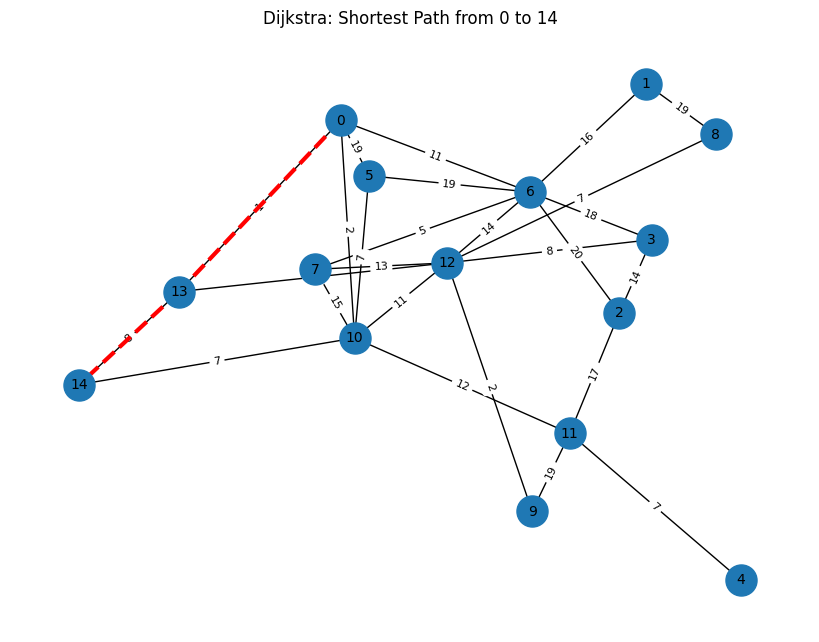

In [3]:
def dijkstra(graph, source):
    distances = {node: float('inf') for node in graph}
    distances[source] = 0
    previous = {node: None for node in graph}
    queue = [(0, source)]
    while queue:
        current_distance, current_node = heapq.heappop(queue)
        if current_distance > distances[current_node]:
            continue
        for neighbor, weight in graph[current_node]:
            new_distance = current_distance + weight
            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (new_distance, neighbor))
    return distances, previous

def reconstruct_path(previous, target):
    # Jika tidak ada jalur ke target, previous[target] akan tetap None (kecuali target = source)
    if previous[target] is None and target != 0:
        return []
    path = []
    while target is not None:
        path.append(target)
        target = previous[target]
    return path[::-1]

dist_dij, pred_dij = dijkstra(graph_adj, source_node)
path_dij = reconstruct_path(pred_dij, target_node)
if len(path_dij) == 0:
    print("Dijkstra: No path found from {} to {}".format(source_node, target_node))
else:
    visualize_path(G, pos, path_dij, "Dijkstra: Shortest Path from {} to {}".format(source_node, target_node))

#### **Penjelasan kode diatas**

- **Fungsi dijkstra(graph, source)**

    - Mengimplementasikan algoritma Dijkstra untuk mencari jarak terpendek dari source ke semua node:

        - Inisialisasi semua jarak ke inf, kecuali source = 0.

        - Gunakan priority queue (min-heap) untuk memilih node dengan jarak terpendek.

        - Lakukan relaksasi untuk semua tetangga jika ditemukan jalur yang lebih pendek.

- **Fungsi reconstruct_path(previous, target)**

    - Merekonstruksi jalur terpendek dari source ke target berdasarkan dictionary previous:

        - Jika target tidak terjangkau, kembalikan list kosong.

        - Jika ada jalur, telusuri previous secara mundur hingga ke source, lalu balikkan urutan.

- **Eksekusi dan Visualisasi**

    - Jalankan dijkstra() untuk mendapatkan jarak (dist_dij) dan jejak jalur (pred_dij).

    - Bangun jalur dari source_node ke target_node menggunakan reconstruct_path.

    - Jika tidak ada jalur, tampilkan pesan. Jika ada, visualisasikan graf dengan jalur terpendek disorot menggunakan visualize_path.

### **B.)** **A* ALGORITHM (minimal menggunakan 2 pendekatan heuristik)**




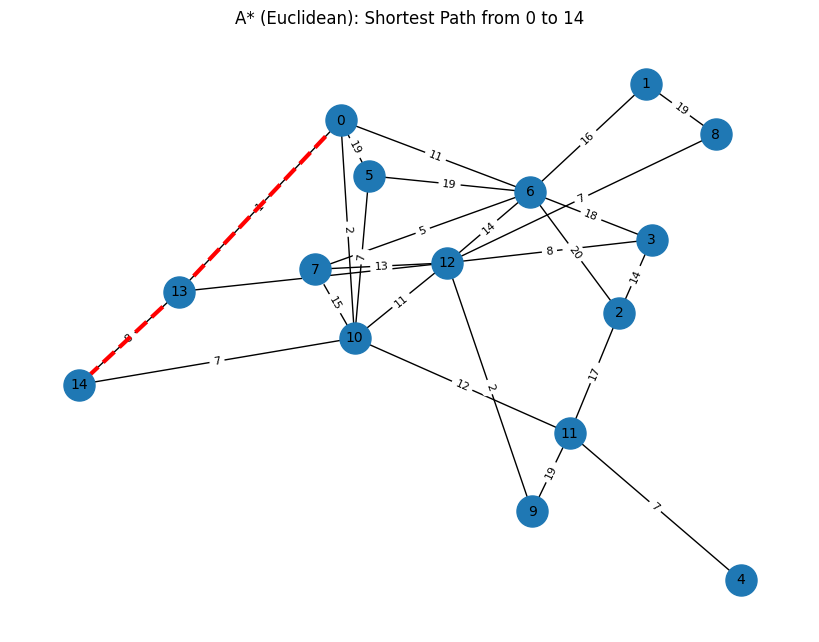

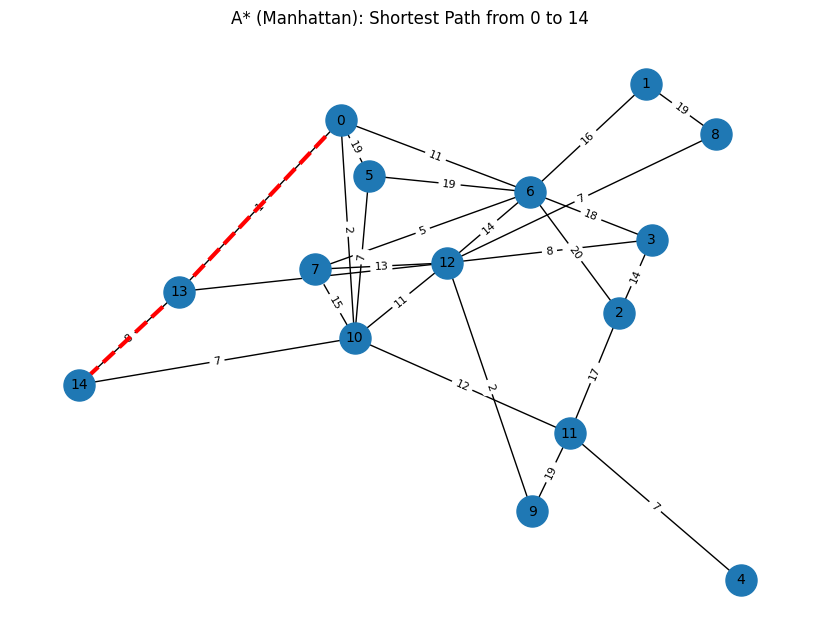

In [4]:
def heuristic_euclidean(node, target, positions):
    x1, y1 = positions[node]
    x2, y2 = positions[target]
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def heuristic_manhattan(node, target, positions):
    x1, y1 = positions[node]
    x2, y2 = positions[target]
    return abs(x1 - x2) + abs(y1 - y2)

def a_star(graph, source, target, heuristic, positions):
    open_set = []
    heapq.heappush(open_set, (0, source))
    came_from = {source: None}
    g_score = {node: float('inf') for node in graph}
    g_score[source] = 0
    f_score = {node: float('inf') for node in graph}
    f_score[source] = heuristic(source, target, positions)
    while open_set:
        current = heapq.heappop(open_set)[1]
        if current == target:
            return g_score[target], reconstruct_path(came_from, target)
        for neighbor, weight in graph[current]:
            tentative_g_score = g_score[current] + weight
            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + heuristic(neighbor, target, positions)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))
    return float('inf'), []

# A* dengan heuristic Euclidean
cost_astar_euclidean, path_astar_euclidean = a_star(graph_adj, source_node, target_node, heuristic_euclidean, pos)
if len(path_astar_euclidean) == 0:
    print("A* (Euclidean): No path found from {} to {}".format(source_node, target_node))
else:
    visualize_path(G, pos, path_astar_euclidean, "A* (Euclidean): Shortest Path from {} to {}".format(source_node, target_node))

# A* dengan heuristic Manhattan
cost_astar_manhattan, path_astar_manhattan = a_star(graph_adj, source_node, target_node, heuristic_manhattan, pos)
if len(path_astar_manhattan) == 0:
    print("A* (Manhattan): No path found from {} to {}".format(source_node, target_node))
else:
    visualize_path(G, pos, path_astar_manhattan, "A* (Manhattan): Shortest Path from {} to {}".format(source_node, target_node))


**Fungsi Heuristik**
- heuristic_euclidean:

Menghitung jarak Euclidean antara node dan target berdasarkan posisi koordinat (positions).

- heuristic_manhattan:

Menghitung jarak Manhattan antara node dan target berdasarkan posisi koordinat.

**Fungsi a_star(...)**
- Merupakan implementasi algoritma A*:

    - Memakai priority queue (open_set) berdasarkan nilai f_score = g_score + heuristic.

    - g_score: jarak sebenarnya dari source ke node saat ini.

    - f_score: prediksi total jarak dari source ke target melalui node saat ini.

    - Jika target ditemukan, jalur dibentuk dengan reconstruct_path.

**Pemanggilan A***
- A* dengan Euclidean

    - Memanggil a_star() dengan heuristic Euclidean.

    - Jika jalur ditemukan, divisualisasikan. Jika tidak, ditampilkan pesan.

- A* dengan Manhattan

    - Sama seperti di atas, tapi menggunakan heuristic Manhattan.

### **C.)** **BELLMAN FORD & FLOYD WARSHAL ALGORITHM**

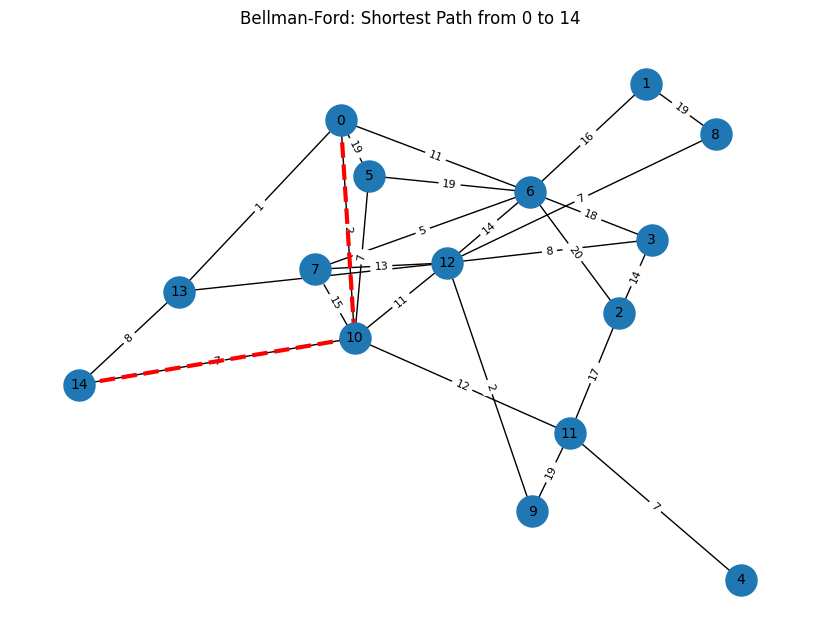

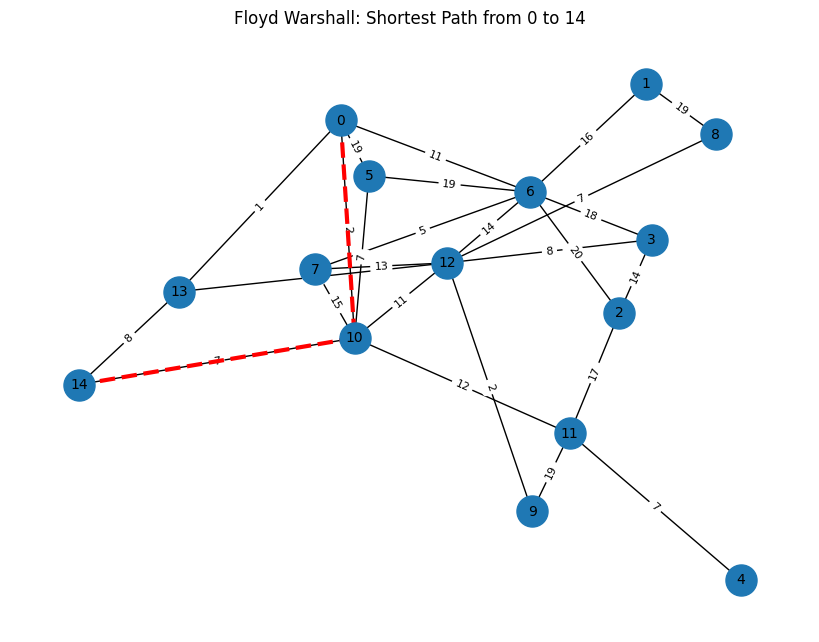

In [5]:
# Bellman-Ford

def bellman_ford(graph, source):
    distances = {node: float('inf') for node in graph}
    distances[source] = 0
    predecessor = {node: None for node in graph}
    nodes = list(graph.keys())
    for _ in range(len(nodes)-1):
        for u in nodes:
            for v, weight in graph[u]:
                if distances[u] + weight < distances[v]:
                    distances[v] = distances[u] + weight
                    predecessor[v] = u
    # Deteksi siklus negatif (tidak diharapkan karena bobot positif)
    for u in nodes:
        for v, weight in graph[u]:
            if distances[u] + weight < distances[v]:
                raise Exception("Graph contains a negative weight cycle")
    return distances, predecessor

dist_bf, pred_bf = bellman_ford(graph_adj, source_node)
path_bf = reconstruct_path(pred_bf, target_node)
if len(path_bf) == 0:
    print("Bellman-Ford: No path found from {} to {}".format(source_node, target_node))
else:
    visualize_path(G, pos, path_bf, "Bellman-Ford: Shortest Path from {} to {}".format(source_node, target_node))



# Floyd Warshall

import numpy as np

def floyd_warshall_with_path(matrix):
    n = matrix.shape[0]
    # Salin matriks dan inisialisasi jarak yang tidak ada edge dengan infinity
    dist = matrix.astype(float).copy()
    for i in range(n):
        for j in range(n):
            if i != j and matrix[i, j] == 0:
                dist[i, j] = np.inf
    # Inisialisasi predecessor (pred)
    pred = np.full((n, n), -1, dtype=int)
    for i in range(n):
        for j in range(n):
            if i != j and matrix[i, j] != 0:
                pred[i, j] = i
    # Algoritma Floyd Warshall
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i, k] + dist[k, j] < dist[i, j]:
                    dist[i, j] = dist[i, k] + dist[k, j]
                    pred[i, j] = pred[k, j]
    return dist, pred

def reconstruct_path_fw(pred, i, j):
    if i == j:
        return [i]
    if pred[i, j] == -1:
        return []
    path = reconstruct_path_fw(pred, i, pred[i, j])
    path.append(j)
    return path

# Contoh penggunaan:
fw_dist, fw_pred = floyd_warshall_with_path(A)
path_fw = reconstruct_path_fw(fw_pred, source_node, target_node)
if len(path_fw) == 0:
    print("Floyd Warshall: No path found from {} to {}".format(source_node, target_node))
else:
    visualize_path(G, pos, path_fw, "Floyd Warshall: Shortest Path from {} to {}".format(source_node, target_node))


#### **Bellman Ford**

Penjelasan Teknis:
- Algoritma ini digunakan untuk mencari jarak terpendek dari satu titik sumber ke semua node dalam graf berbobot, termasuk yang memiliki bobot negatif.

- Langkah pertama adalah inisialisasi semua jarak ke ∞ (tak hingga), kecuali node sumber (0).

- Dilakukan relaksasi terhadap semua edge sebanyak |V| - 1 kali, di mana |V| adalah jumlah simpul (node).

- Setelah relaksasi, dilakukan satu iterasi tambahan untuk mengecek keberadaan siklus negatif.

- Fungsi ini mengembalikan dua objek:

    - distances: Jarak minimum dari sumber ke tiap node.

    - predecessor: Node sebelumnya untuk setiap node (untuk keperluan rekonstruksi jalur).

- Visualisasi dilakukan hanya jika ditemukan jalur dari node sumber ke tujuan.

#### **Floyd Warshall**

Penjelasan Teknis:
- Floyd-Warshall adalah algoritma all-pairs shortest path yang menghitung jarak terpendek antara setiap pasangan simpul dalam graf.

- Kompleksitas waktu: O(V³) — menggunakan 3 tingkat perulangan.

- Matriks dist digunakan untuk menyimpan jarak antar simpul.

- Matriks pred menyimpan informasi predecessor dari simpul agar dapat direkonstruksi jalurnya.

- Prinsip dasarnya:

    - Jika melalui simpul k memberikan jarak lebih pendek dari i ke j, maka dist[i][j] diperbarui, dan pred[i][j] diatur ke pred[k][j].

- Fungsi reconstruct_path_fw(pred, i, j) digunakan untuk membangun jalur dari node i ke j berdasarkan informasi dalam matriks pred.

#### **Pemanggilan dan Visualisasi**

Penjelasan Teknis:
- Setelah masing-masing algoritma dijalankan:

    - Jalur terpendek dari node sumber ke target direkonstruksi menggunakan fungsi rekonstruksi jalur.

    - Jika jalur ditemukan, maka fungsi visualize_path() dipanggil untuk menampilkan jalur terpendek pada graf.

- Fungsi visualize_path() menampilkan graf dengan menyorot edge jalur terpendek menggunakan warna dan gaya khusus (misalnya, garis putus-putus merah).

### **D.)** **JOHNSHON ALGORITHM**

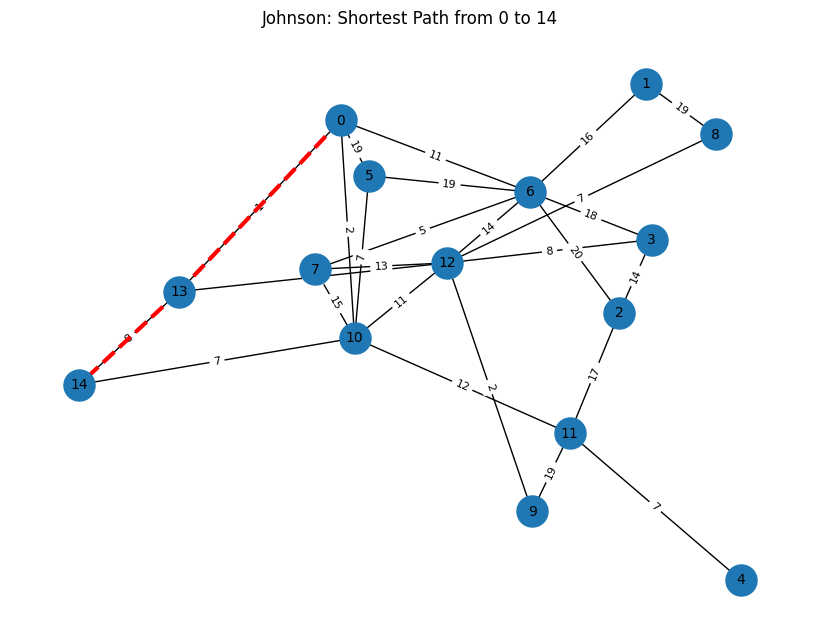

In [6]:
def johnson(graph_adj):
    nodes = list(graph_adj.keys())
    new_node = max(nodes) + 1
    new_graph = {}
    for u in graph_adj:
        new_graph[u] = list(graph_adj[u])
    new_graph[new_node] = [(u, 0) for u in nodes]
    try:
        h, _ = bellman_ford(new_graph, new_node)
    except Exception as e:
        print("Johnson algorithm error:", e)
        return None, None, None
    reweighted_graph = {}
    for u in graph_adj:
        reweighted_graph[u] = []
        for v, weight in graph_adj[u]:
            new_weight = weight + h[u] - h[v]
            reweighted_graph[u].append((v, new_weight))
    distances_all = {}
    predecessors_all = {}
    n = len(graph_adj)
    matrix = np.zeros((n, n))
    for u in graph_adj:
        d, pred = dijkstra(reweighted_graph, u)
        distances_all[u] = d
        predecessors_all[u] = pred
        for v in range(n):
            if d[v] != float('inf'):
                matrix[u,v] = d[v] - h[u] + h[v]
            else:
                matrix[u,v] = float('inf')
    return matrix, distances_all, predecessors_all

matrix_johnson, distances_johnson, preds_johnson = johnson(graph_adj)
if matrix_johnson is None:
    print("Johnson algorithm failed.")
else:
    path_johnson = reconstruct_path(preds_johnson[source_node], target_node)
    if len(path_johnson) == 0:
        print("Johnson: No path found from {} to {}".format(source_node, target_node))
    else:
        visualize_path(G, pos, path_johnson, "Johnson: Shortest Path from {} to {}".format(source_node, target_node))

**Fungsi johnson(graph_adj)**
- Menghitung jarak terpendek semua pasang node (all-pairs shortest path) dengan Johnson’s Algorithm:

    - Tambahkan node baru (new_node) yang terhubung ke semua node dengan bobot 0.

    - Jalankan Bellman-Ford dari new_node untuk memperoleh potential h[u].

    - Reweight edge agar semua bobot menjadi non-negatif:

        - w'(u,v) = w(u,v) + h[u] - h[v]

    - Jalankan Dijkstra untuk setiap node u pada graf yang telah di-reweight.

    - Kembalikan bobot asli dengan rumus:

        - d(u,v) = d'(u,v) - h[u] + h[v]

    - Hasil berupa:

        - matrix: matriks jarak terpendek semua pasang node.

        - distances_all: jarak dari setiap node ke node lain.

        - predecessors_all: parent node untuk membentuk jalur terpendek.

**Eksekusi dan Visualisasi**
- Panggil fungsi johnson() pada graph_adj.

- Jika berhasil, ambil predecessor dari source_node ke target_node, lalu bangun jalur dengan reconstruct_path.

- Jika jalur ditemukan, tampilkan graf dengan jalur terpendek menggunakan visualize_path.

### Lakukan analisis kelebihan dan kelemahan masing - masing algorithm, dan buatkan tabel atau infografis lainnya berupa hasil evaluasi performa masing - masing algoritma

#### **Analisis Kelebihan dan Kekurangan Algoritma**

1. Dijkstra’s Algorithm
    - Kelebihan:

        - Efisiensi: Kompleksitas waktu O(V log V + E) membuatnya sangat efisien untuk graf dengan bobot non-negatif, terutama pada graf jarang.

        - Implementasi Sederhana: Algoritma ini relatif mudah dipahami dan diimplementasikan dengan struktur data priority queue.

        - Cocok untuk Single-Source: Sangat ideal untuk mencari jalur terpendek dari satu sumber ke semua node dalam graf tanpa bobot negatif.

    - Kekurangan:

        - Keterbatasan Bobot Negatif: Tidak dapat menangani graf dengan bobot negatif, sehingga tidak fleksibel untuk semua jenis graf.

        - Skalabilitas pada Graf Dens: Pada graf yang sangat padat (dense graph), meski menggunakan priority queue, overhead-nya bisa meningkat.

2. A* Algorithm
    - Kelebihan:

        - Pemanfaatan Heuristik: Dengan menggunakan fungsi heuristic (misalnya Euclidean atau Manhattan), A* dapat mengarahkan pencarian sehingga seringkali lebih cepat daripada Dijkstra pada kasus pathfinding.

        - Efisiensi dalam Pencarian Spasial: Sangat efektif pada aplikasi yang melibatkan grid atau peta, di mana estimasi jarak dapat secara signifikan mempercepat pencarian.

        - Optimalitas: Dengan heuristic yang admissible (tidak pernah melebih-lebihkan biaya sebenarnya), A* tetap memberikan solusi optimal.

    - Kekurangan:

        - Ketergantungan pada Heuristik: Kinerja algoritma sangat bergantung pada pemilihan fungsi heuristic. Heuristic yang kurang tepat dapat membuat A* hampir seefisien Dijkstra atau bahkan lebih lambat.

        - Pengaturan Parameter: Merancang dan menguji beberapa heuristic untuk menemukan yang paling sesuai bisa memakan waktu dan usaha ekstra.

        - Overhead Perhitungan Heuristik: Setiap langkah pencarian harus menghitung nilai heuristic, yang bisa menambah overhead, terutama pada graf yang besar.

3. Bellman-Ford Algorithm
    - Kelebihan:

        - Menangani Bobot Negatif: Dapat menghitung jalur terpendek pada graf dengan bobot negatif dan juga mendeteksi keberadaan siklus negatif.

        - Sederhana dan Langsung: Algoritma ini cukup intuitif dengan pendekatan relaxation yang berulang.

    - Kekurangan:

        - Kompleksitas Waktu Tinggi: Kompleksitas O(V * E) membuatnya jauh lebih lambat dibandingkan Dijkstra pada graf yang besar atau graf dengan semua bobot non-negatif.

        - Kurang Efisien untuk Graf Besar: Jika graf tidak mengandung bobot negatif, penggunaan Bellman-Ford bisa dianggap overkill dan tidak optimal.

4. Floyd Warshall Algorithm
    - Kelebihan:

        - All-Pairs Shortest Paths: Secara simultan menghitung jarak terpendek antara semua pasang node, cocok jika dibutuhkan informasi lengkap.

        - Implementasi Konsep Dinamis: Algoritma ini menggunakan pendekatan dynamic programming yang sederhana dan mudah diikuti.

    - Kekurangan:

        - Kompleksitas Tiga Tingkat: Waktu eksekusi O(V³) dan memori O(V²) membuatnya tidak efisien untuk graf besar.

        - Keterbatasan pada Graf Besar: Karena kompleksitasnya, algoritma ini lebih sesuai untuk graf kecil atau sedang.

5. Johnson Algorithm
    - Kelebihan:

        - Efisiensi pada Graf Jarang: Menggabungkan Bellman-Ford dan Dijkstra sehingga dapat menghitung all-pairs shortest paths secara efisien pada graf jarang (sparse).

        - Menangani Bobot Negatif: Mampu menangani bobot negatif selama tidak ada siklus negatif, sehingga lebih fleksibel.

        - Skalabilitas untuk All-Pairs: Memberikan alternatif yang lebih efisien daripada Floyd Warshall untuk graf besar yang jarang.

    - Kekurangan:

        - Implementasi Kompleks: Proses reweighting dan penggunaan dua algoritma berbeda menambah kompleksitas implementasi.

        - Overhead Tambahan: Tahap awal menggunakan Bellman-Ford untuk menghitung potensi (h) dapat menjadi overhead yang tidak diperlukan jika graf tidak memiliki bobot negatif.

        - Kinerja Tergantung pada Graf: Untuk graf yang padat, Johnson mungkin tidak memberikan keuntungan performa yang signifikan dibandingkan Floyd Warshall.

#### **Analisis perbandingan dari 3 parameter yang digunakan pada masing-masing algoritma**

**Tujuan:**
- Mengevaluasi dan membandingkan 6 algoritma shortest path berdasarkan:

    - Waktu eksekusi (rata-rata ms)

    - Penggunaan memori (rata-rata KB)

    - Total bobot jalur terpendek dari source_node ke target_node

Dijkstra:
  Time (ms): 0.008606001501902938
  Memory (KB): 1.4609375
  Total Weight: 9

A* (Euclidean):
  Time (ms): 0.01991199911572039
  Memory (KB): 1.8315234375
  Total Weight: 9

A* (Manhattan):
  Time (ms): 0.020893001928925514
  Memory (KB): 2.0654296875
  Total Weight: 9

Bellman-Ford:
  Time (ms): 0.042402001563459635
  Memory (KB): 1.4609375
  Total Weight: 9

Floyd Warshall:
  Time (ms): 0.9279719984624535
  Memory (KB): 3.90625
  Total Weight: 9.0

Johnson:
  Time (ms): 0.22954100044444203
  Memory (KB): 24.453125
  Total Weight: 9.0

        Algorithm  Time (ms)  Memory (KB)  Total Weight
0        Dijkstra   0.008606     1.460938           9.0
1  A* (Euclidean)   0.019912     1.831523           9.0
2  A* (Manhattan)   0.020893     2.065430           9.0
3    Bellman-Ford   0.042402     1.460938           9.0
4  Floyd Warshall   0.927972     3.906250           9.0
5         Johnson   0.229541    24.453125           9.0


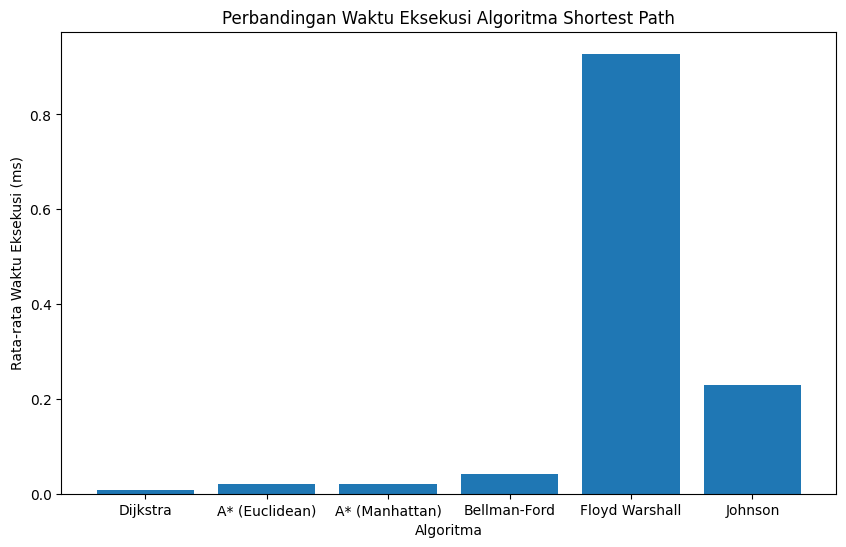

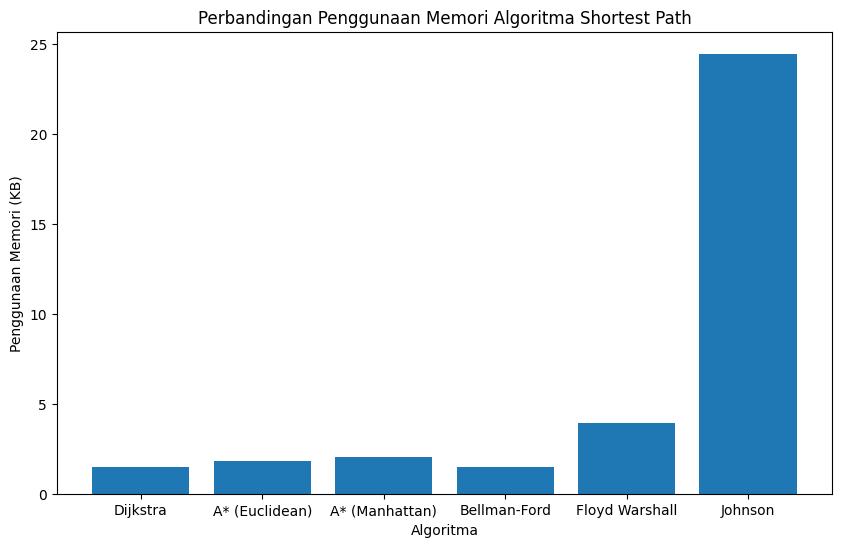

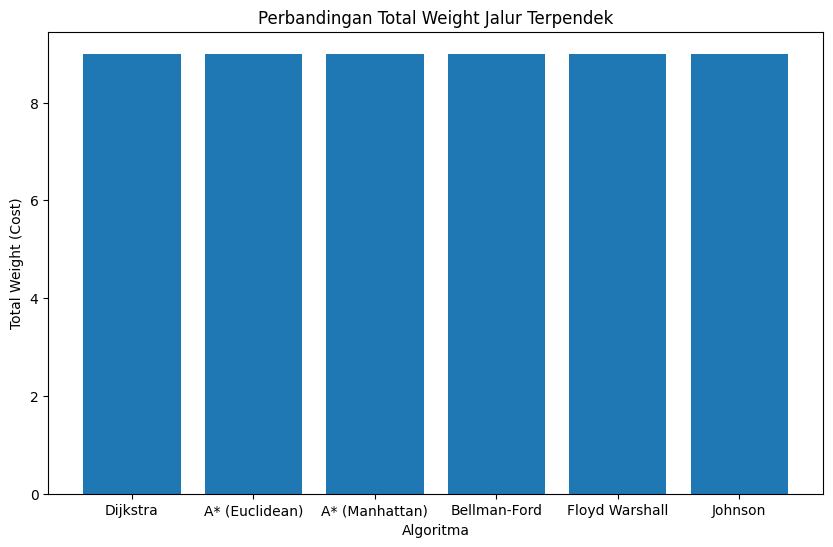

In [7]:
import time
import tracemalloc
import matplotlib.pyplot as plt
import pandas as pd

# Fungsi untuk mengukur rata-rata waktu eksekusi dalam milidetik
def avg_time(func, iterations=100, *args, **kwargs):
    total_time = 0
    for _ in range(iterations):
        start = time.perf_counter()
        func(*args, **kwargs)
        end = time.perf_counter()
        total_time += (end - start)
    return (total_time / iterations) * 1000  # konversi ke ms

# Fungsi untuk mengukur rata-rata penggunaan memori (peak) dalam KB
def avg_memory(func, iterations=100, *args, **kwargs):
    total_memory = 0
    for _ in range(iterations):
        tracemalloc.start()
        func(*args, **kwargs)
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        total_memory += peak  # peak dalam byte
    # Rata-rata dalam KB
    return (total_memory / iterations) / 1024

# ======================
# Total weight dari solusi (jalur dari source ke target)
# ======================

# Untuk Dijkstra
def total_weight_dijkstra():
    distances, _ = dijkstra(graph_adj, source_node)
    return distances[target_node]

# Untuk A* (Euclidean)
def total_weight_astar_euclidean():
    cost, _ = a_star(graph_adj, source_node, target_node, heuristic_euclidean, pos)
    return cost

# Untuk A* (Manhattan)
def total_weight_astar_manhattan():
    cost, _ = a_star(graph_adj, source_node, target_node, heuristic_manhattan, pos)
    return cost

# Untuk Bellman-Ford
def total_weight_bellman_ford():
    distances, _ = bellman_ford(graph_adj, source_node)
    return distances[target_node]

# Untuk Floyd Warshall (menggunakan fungsi floyd_warshall_with_path)
def total_weight_floyd():
    fw_dist, _ = floyd_warshall_with_path(A)
    return fw_dist[source_node, target_node]

# Untuk Johnson
def total_weight_johnson():
    matrix, _, _ = johnson(graph_adj)
    return matrix[source_node, target_node]

# ======================
# Asumsikan fungsi-fungsi berikut sudah terdefinisi:
# dijkstra, a_star, bellman_ford, floyd_warshall_with_path, johnson, reconstruct_path
# Selain itu, variabel: graph_adj, A, source_node, target_node, pos, heuristic_euclidean, heuristic_manhattan
# ======================

# Jumlah iterasi pengukuran
iterations = 100

time_dijkstra = avg_time(dijkstra, iterations, graph_adj, source_node)
time_astar_e = avg_time(a_star, iterations, graph_adj, source_node, target_node, heuristic_euclidean, pos)
time_astar_m = avg_time(a_star, iterations, graph_adj, source_node, target_node, heuristic_manhattan, pos)
time_bellman_ford = avg_time(bellman_ford, iterations, graph_adj, source_node)
time_floyd = avg_time(floyd_warshall_with_path, iterations, A)
time_johnson = avg_time(johnson, iterations, graph_adj)

mem_dijkstra = avg_memory(dijkstra, iterations, graph_adj, source_node)
mem_astar_e = avg_memory(a_star, iterations, graph_adj, source_node, target_node, heuristic_euclidean, pos)
mem_astar_m = avg_memory(a_star, iterations, graph_adj, source_node, target_node, heuristic_manhattan, pos)
mem_bellman_ford = avg_memory(bellman_ford, iterations, graph_adj, source_node)
mem_floyd = avg_memory(floyd_warshall_with_path, iterations, A)
mem_johnson = avg_memory(johnson, iterations, graph_adj)

# Total weight (hanya satu kali pemanggilan, karena hasil deterministik)
weight_dijkstra = total_weight_dijkstra()
weight_astar_e = total_weight_astar_euclidean()
weight_astar_m = total_weight_astar_manhattan()
weight_bellman_ford = total_weight_bellman_ford()
weight_floyd = total_weight_floyd()
weight_johnson = total_weight_johnson()

# Simpan hasil pengukuran ke dalam dictionary
results = {
    "Dijkstra": {"Time (ms)": time_dijkstra, "Memory (KB)": mem_dijkstra, "Total Weight": weight_dijkstra},
    "A* (Euclidean)": {"Time (ms)": time_astar_e, "Memory (KB)": mem_astar_e, "Total Weight": weight_astar_e},
    "A* (Manhattan)": {"Time (ms)": time_astar_m, "Memory (KB)": mem_astar_m, "Total Weight": weight_astar_m},
    "Bellman-Ford": {"Time (ms)": time_bellman_ford, "Memory (KB)": mem_bellman_ford, "Total Weight": weight_bellman_ford},
    "Floyd Warshall": {"Time (ms)": time_floyd, "Memory (KB)": mem_floyd, "Total Weight": weight_floyd},
    "Johnson": {"Time (ms)": time_johnson, "Memory (KB)": mem_johnson, "Total Weight": weight_johnson}
}

# Tampilkan hasil pengukuran
for algo, metrics in results.items():
    print(f"{algo}:")
    for key, value in metrics.items():
        print(f"  {key}: {value}")
    print()

# Buat DataFrame untuk menampilkan hasil
df = pd.DataFrame({
    "Algorithm": list(results.keys()),
    "Time (ms)": [results[algo]["Time (ms)"] for algo in results],
    "Memory (KB)": [results[algo]["Memory (KB)"] for algo in results],
    "Total Weight": [results[algo]["Total Weight"] for algo in results]
})

# Jika menggunakan Jupyter Notebook, cukup tulis:
df

# Jika tidak, gunakan print:
print(df)

# Bar Chart untuk Waktu Eksekusi
plt.figure(figsize=(10,6))
plt.bar(df["Algorithm"], df["Time (ms)"])
plt.xlabel("Algoritma")
plt.ylabel("Rata-rata Waktu Eksekusi (ms)")
plt.title("Perbandingan Waktu Eksekusi Algoritma Shortest Path")
plt.show()

# Bar Chart untuk Penggunaan Memori
plt.figure(figsize=(10,6))
plt.bar(df["Algorithm"], df["Memory (KB)"])
plt.xlabel("Algoritma")
plt.ylabel("Penggunaan Memori (KB)")
plt.title("Perbandingan Penggunaan Memori Algoritma Shortest Path")
plt.show()

# Bar Chart untuk Total Weight
plt.figure(figsize=(10,6))
plt.bar(df["Algorithm"], df["Total Weight"])
plt.xlabel("Algoritma")
plt.ylabel("Total Weight (Cost)")
plt.title("Perbandingan Total Weight Jalur Terpendek")
plt.show()


**Bagian Utama:**
1. avg_time() dan avg_memory()
- Mengukur:

    - Waktu rata-rata eksekusi fungsi (100 kali)

    - Memori puncak rata-rata (menggunakan tracemalloc)

2. total_weight_*()
- Mengembalikan total cost dari jalur terpendek untuk setiap algoritma (sekali eksekusi saja karena hasilnya deterministik).

3. Eksekusi Pengukuran
- Untuk setiap algoritma (Dijkstra, A*, Bellman-Ford, Floyd-Warshall, Johnson), dilakukan:

    - avg_time(...)

    - avg_memory(...)

    - total_weight_...()

4. Penyimpanan Hasil
- Hasil pengukuran disimpan dalam dictionary results dan ditampilkan dalam bentuk:

    - Teks (print)

    - Tabel (pandas.DataFrame)

    - Visualisasi (bar chart) untuk masing-masing metrik

**Output:**
- Tabel dan grafik yang menunjukkan:

    - Algoritma mana yang tercepat

    - Mana yang paling hemat memori

    - Mana yang menghasilkan jalur terpendek (total weight paling kecil)



### >> **[SOAL NOMOR 2]** Buatlah sebuah daftar ketetanggan graf berbobot dengan 10 node berukuran, (generate menggunakan nilai random), kemudian sajikan pembahasan anda secara mendalam terkait implementasi algoritma minimum spanning tree menggunakan :



### **Membuat graf**

Adjacency Matrix (Graf Sparse):
[[ 0 15  0  0 19 11  0  0  0  2]
 [15  0  0  0  1 12 10 16 15  0]
 [ 0  0  0 20  0 19  0  0 14  0]
 [ 0  0 20  0  2  0  0  8 14 18]
 [19  1  0  2  0  0  6  4 18  0]
 [11 12 19  0  0  0  0  0  0  0]
 [ 0 10  0  0  6  0  0  8  0  0]
 [ 0 16  0  8  4  0  8  0  0  0]
 [ 0 15 14 14 18  0  0  0  0  0]
 [ 2  0  0 18  0  0  0  0  0  0]]


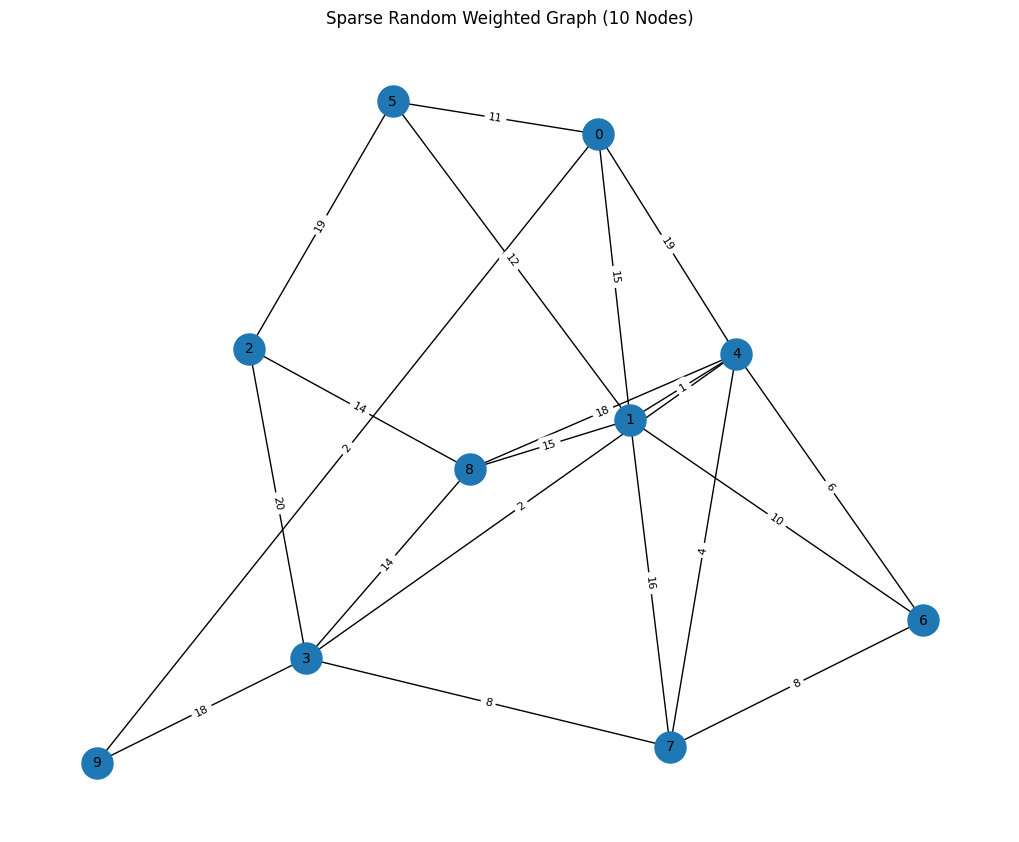

In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import heapq
import math

np.random.seed(42)
n = 10 # jumlah vertex
p = 0.4  # probabilitas adanya edge antara dua vertex

# Buat matriks ketetanggaan kosong
A = np.zeros((n, n), dtype=int)

# Isi matriks secara acak: untuk i < j, jika random < p, maka assign bobot random antara 1 dan 20
for i in range(n):
    for j in range(i+1, n):
        if np.random.rand() < p:
            A[i, j] = np.random.randint(1, 21)

# Karena graf tidak berarah, simetriskan matriks
A = A + A.T

# Pastikan diagonal adalah 0 (tidak ada self-loop)
np.fill_diagonal(A, 0)

print("Adjacency Matrix (Graf Sparse):")
print(A)

# Buat graf dari matriks
G = nx.from_numpy_array(A)

# Visualisasi graf
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Sparse Random Weighted Graph (10 Nodes)")
plt.show()

In [16]:
def visualize_mst(G, pos, mst_edges, title):
    """
    Menampilkan visualisasi graf dengan MST (edge MST disorot dengan warna merah).
    """
    plt.figure(figsize=(8,6))
    # Gambar graf asli dengan tingkat transparansi
    nx.draw(G, pos, with_labels=True, node_size=500, font_size=10, alpha=0.3)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'), font_size=8)
    # Ambil edge-edge MST
    mst_edge_list = [(u, v) for u, v, w in mst_edges]
    nx.draw_networkx_edges(G, pos, edgelist=mst_edge_list, width=3, edge_color='r')
    plt.title(title)
    plt.show()

##### **Penjelasan kode**

1. Pembuatan Graf Berbobot Acak
- Membuat graf tak berarah berbobot sebanyak 10 simpul (n = 10).

- Matriks ketetanggaan (adjacency matrix) dibentuk menggunakan numpy.

- Edge antar node ditentukan secara acak dengan probabilitas p = 0.4.

- Bobot setiap edge diacak antara 1 hingga 20.

- Matriks disimetriskan agar graf menjadi tak berarah.

- Tidak ada self-loop karena diagonal diset ke 0.

2. Visualisasi Graf
- Graf dibangun menggunakan networkx.from_numpy_array(A).

- Posisi simpul dihitung menggunakan spring_layout untuk visualisasi yang rapi.

- Semua node dan edge divisualisasikan menggunakan matplotlib, lengkap dengan label bobot pada setiap edge.

3. Fungsi visualize_mst
- Fungsi ini digunakan untuk menampilkan hasil MST (Minimum Spanning Tree).

- Graf asli digambar dengan transparansi (alpha=0.3), sedangkan edge MST disorot dengan garis merah tebal.

- Parameter fungsi:

    - G: graf asli

    - pos: posisi node (agar tidak berubah antar plot)

    - mst_edges: daftar edge MST dalam format (u, v, w)

    - title: judul graf

- Label bobot edge tetap ditampilkan.

- Cocok digunakan setelah menjalankan algoritma Prim atau Kruskal.

### **A.)** **KRUSKAL'S ALGORITHM**



Kruskal's MST Edges: [(1, 4, 1), (0, 9, 2), (3, 4, 2), (4, 7, 4), (4, 6, 6), (0, 5, 11), (1, 5, 12), (2, 8, 14), (3, 8, 14)]
Total Weight (Kruskal): 66


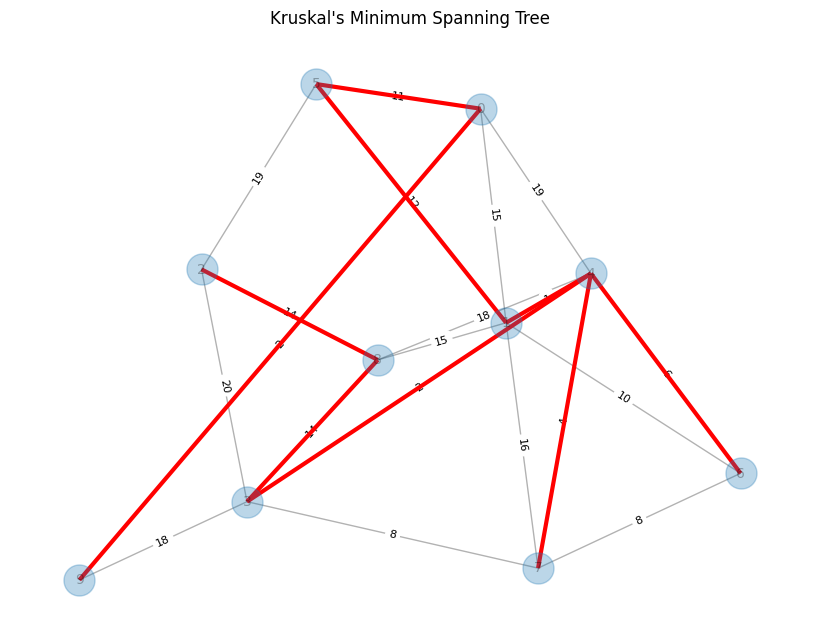

In [10]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, u):
        if self.parent[u] != u:
            self.parent[u] = self.find(self.parent[u])
        return self.parent[u]
    def union(self, u, v):
        root_u = self.find(u)
        root_v = self.find(v)
        if root_u != root_v:
            self.parent[root_v] = root_u

def kruskal_mst(G, num_nodes):
    """
    Menghasilkan MST menggunakan Kruskal’s Algorithm.
    Mengembalikan list edge MST (u, v, w) dan total bobot MST.
    """
    edges = []
    for u, v, data in G.edges(data=True):
        w = data['weight']
        edges.append((w, u, v))
    edges.sort(key=lambda x: x[0])
    uf = UnionFind(num_nodes)
    mst_edges = []
    total_weight = 0
    for w, u, v in edges:
        if uf.find(u) != uf.find(v):
            uf.union(u, v)
            mst_edges.append((u, v, w))
            total_weight += w
    return mst_edges, total_weight

mst_kruskal, total_weight_kruskal = kruskal_mst(G, n)
print("Kruskal's MST Edges:", mst_kruskal)
print("Total Weight (Kruskal):", total_weight_kruskal)
visualize_mst(G, pos, mst_kruskal, "Kruskal's Minimum Spanning Tree")

#### **Penjelasan Implementasi Kruskal's Algorithm**
1. Union-Find (Disjoint Set)
- Digunakan untuk mendeteksi apakah dua simpul sudah berada dalam satu komponen terhubung (agar tidak membentuk siklus).

    - __init__: setiap simpul awalnya menjadi parent dirinya sendiri.

    - find(u): mencari root dari node u, menggunakan path compression untuk efisiensi.

    - union(u, v): menggabungkan dua himpunan jika root-nya berbeda (tidak membentuk siklus).

2. Fungsi kruskal_mst(G, num_nodes)
- Tujuannya adalah membangun Minimum Spanning Tree (MST) dari graf G dengan strategi greedy.

- Langkah-langkahnya:
    - Ambil seluruh edge dari graf G beserta bobotnya dan simpan sebagai (weight, u, v).

    - Urutkan edge berdasarkan bobot dari kecil ke besar.

    - Inisialisasi struktur Union-Find untuk membantu mendeteksi siklus.

    - Iterasi setiap edge terurut:

        - Jika u dan v tidak berada dalam komponen yang sama, tambahkan edge ke MST.

        - Gabungkan komponen menggunakan union().

        - Tambahkan bobot edge ke total MST.

    - Kembalikan hasil:

        - Daftar edge yang membentuk MST.

        - Total bobot MST.

3. Eksekusi dan Visualisasi
- Fungsi kruskal_mst() dipanggil untuk menghitung MST dari graf.

- Hasilnya dicetak: daftar edge MST dan total bobotnya.

- MST divisualisasikan menggunakan fungsi visualize_mst():

    - Edge yang masuk MST disorot berwarna merah.

    - Graf asli ditampilkan samar sebagai latar belakang.



### **B.)** **PRIM'S ALGORITHM**


Prim's MST Edges: [(0, 9, 2), (0, 5, 11), (5, 1, 12), (1, 4, 1), (4, 3, 2), (4, 7, 4), (4, 6, 6), (3, 8, 14), (8, 2, 14)]
Total Weight (Prim): 66


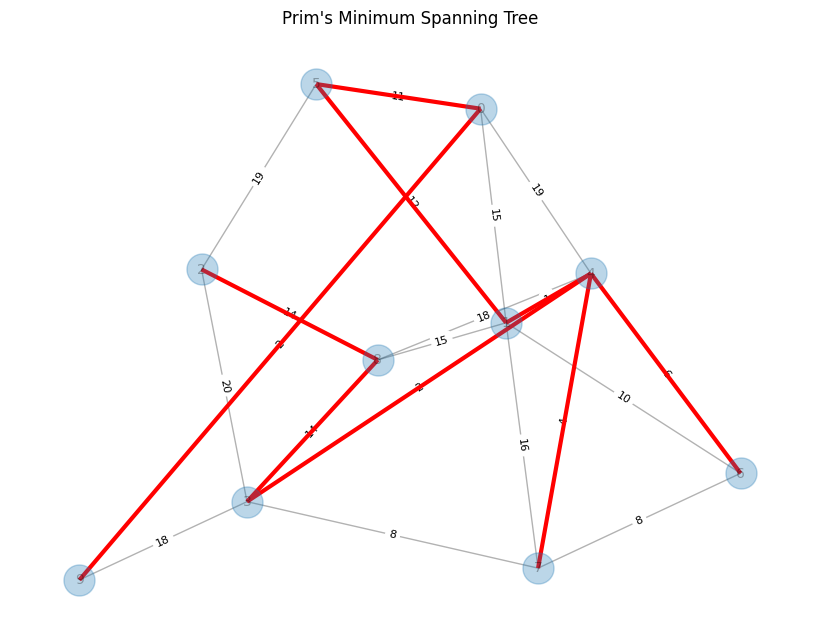

In [11]:
def prim_mst(G, start=0):
    """
    Menghasilkan MST menggunakan Prim’s Algorithm.
    Mengembalikan list edge MST (u, v, w) dan total bobot MST.
    """
    num_nodes = G.number_of_nodes()
    visited = set([start])
    edges = []
    mst_edges = []
    total_weight = 0
    # Tambahkan semua edge dari node start ke heap
    for v in G.neighbors(start):
        w = G[start][v]['weight']
        heapq.heappush(edges, (w, start, v))
    while edges and len(visited) < num_nodes:
        w, u, v = heapq.heappop(edges)
        if v not in visited:
            visited.add(v)
            mst_edges.append((u, v, w))
            total_weight += w
            for neighbor in G.neighbors(v):
                if neighbor not in visited:
                    heapq.heappush(edges, (G[v][neighbor]['weight'], v, neighbor))
    return mst_edges, total_weight

mst_prim, total_weight_prim = prim_mst(G, start=0)
print("Prim's MST Edges:", mst_prim)
print("Total Weight (Prim):", total_weight_prim)
visualize_mst(G, pos, mst_prim, "Prim's Minimum Spanning Tree")

#### **Penjelasan Implementasi Prim's Algorithm**
1. Fungsi prim_mst(G, start=0)
- Fungsi ini digunakan untuk menghitung Minimum Spanning Tree (MST) dari sebuah graf berbobot tak berarah menggunakan Prim’s Algorithm, dimulai dari node start (default = 0).

- Inisialisasi:
    - num_nodes: jumlah simpul dalam graf.

    - visited: set yang menyimpan simpul yang sudah masuk ke MST (dimulai dari start).

    - edges: min-heap (priority queue) untuk menyimpan edge yang siap diproses.

    - mst_edges: list hasil akhir yang menyimpan edge-edge terpilih.

    - total_weight: menjumlahkan total bobot edge dalam MST.

- Langkah Awal:
    - Semua edge yang terhubung ke node awal (start) dimasukkan ke dalam heap edges dengan format (bobot, node_asal, node_tujuan).

2. Proses Iteratif:
- Selama masih ada edge dalam heap dan jumlah node di visited belum sebanyak total node:

    - Ambil edge dengan bobot terkecil dari heap (heapq.heappop).

    - Jika node tujuan (v) belum dikunjungi, maka:

        - Tambahkan v ke visited.

        - Masukkan edge (u, v, w) ke mst_edges.

        - Tambahkan bobot ke total_weight.

        - Masukkan semua edge dari v ke node lain yang belum dikunjungi ke dalam heap.

3. Return Hasil
- Setelah proses selesai, fungsi mengembalikan:

    - mst_edges: daftar edge dalam MST.

    - total_weight: total bobot seluruh edge di dalam MST.

4. Eksekusi & Visualisasi
- Setelah fungsi dijalankan:

    - Nilai mst_prim berisi daftar edge MST hasil Prim.

    - Nilai total_weight_prim menyimpan total bobot MST.

    - Visualisasi menggunakan visualize_mst():

        - Graf asli ditampilkan samar.

        - Edge hasil MST disorot berwarna merah untuk memperjelas struktur pohon minimum.



### Lakukan analisis kelebihan dan kelemahan masing - masing algorithm, dan buatkan tabel atau infografis lainnya berupa hasil evaluasi performa masing - masing algoritma



#### **Analisis kelebihan dan kekurangan**

##### **Kruskal’s Algorithm**
- Kelebihan:
    - Sederhana dan intuitif: Cocok untuk implementasi dasar dan pengajaran konsep MST.

    - Efisien untuk graf sparse: Karena hanya memproses edge yang relevan (tidak harus mengeksplor semua tetangga).

    - Tidak tergantung pada node awal.

    - Cocok untuk representasi graf sebagai edge list.

- Kekurangan:
    - Perlu struktur data Union-Find untuk efisiensi, terutama untuk menghindari siklus.

    - Kurang optimal pada graf padat (dense) karena harus menyortir banyak edge.

    - Tidak memberikan jalur bertahap seperti Prim (yang bisa berguna di aplikasi real-time/networking).

##### **Prim’s Algorithm**
- Kelebihan:
    - Efisien untuk graf padat: Menggunakan priority queue untuk memilih edge minimum secara lokal.

    - Lebih cepat jika graf direpresentasikan sebagai adjacency list.

    - Memberikan jalur bertahap (greedy growing) dari satu simpul ke seluruh graf.

    - Lebih mudah diadaptasi ke struktur online/streaming (misalnya jaringan bertambah).

- Kekurangan:
    - Tergantung pada simpul awal (meskipun hasil akhir tetap MST).

    - Implementasi bisa lebih kompleks karena menggunakan heap dan pelacakan node visited.

    - Untuk graf sparse dengan edge list, performanya kalah dibanding Kruskal.



#### **Hasil evaluasi performa algoritma**

Evaluasi Performa MST:
  Algorithm  Execution Time (ms)  Memory Usage (KB)  Total Weight
0   Kruskal             0.013247           1.296875            66
1      Prim             0.014029           1.031250            66


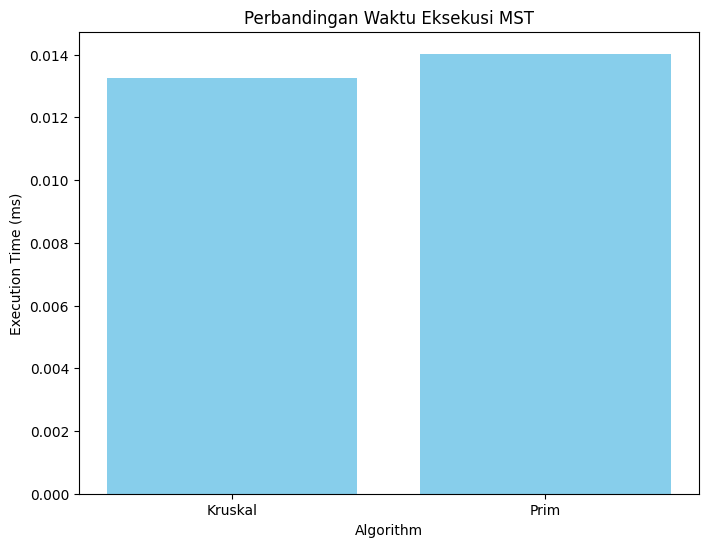

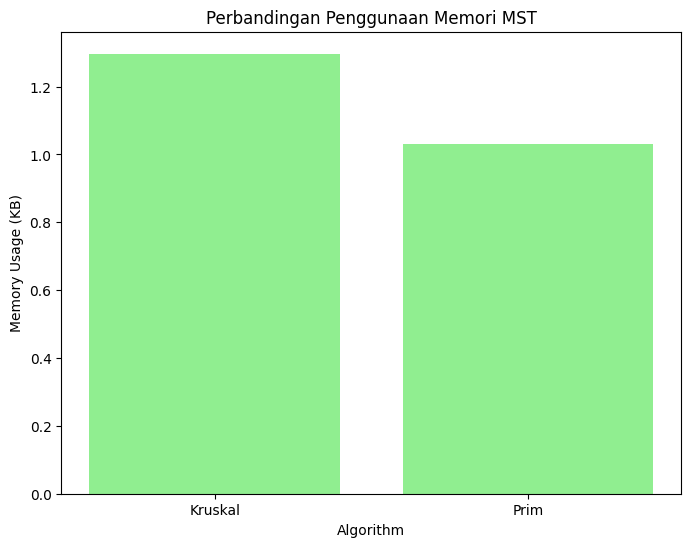

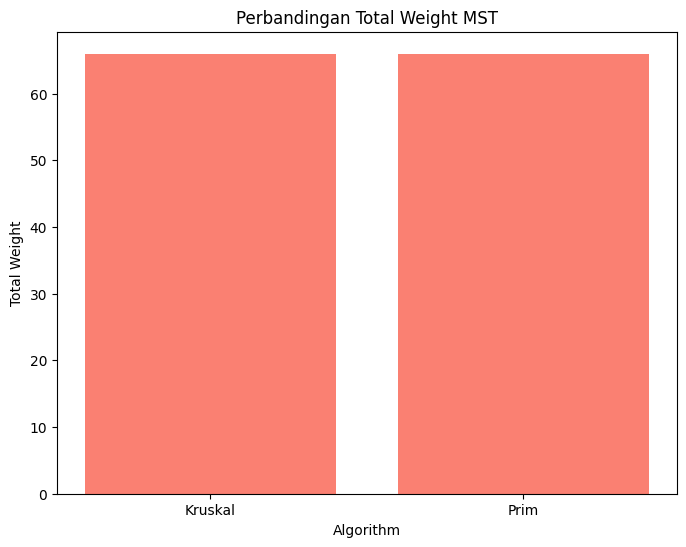

In [12]:
import time
import tracemalloc
import matplotlib.pyplot as plt
import pandas as pd

# ======================
# Fungsi Pengukuran
# ======================
def avg_time(func, iterations=100, *args, **kwargs):
    total_time = 0
    for _ in range(iterations):
        start = time.perf_counter()
        func(*args, **kwargs)
        end = time.perf_counter()
        total_time += (end - start)
    return (total_time / iterations) * 1000  # konversi ke milidetik

def avg_memory(func, iterations=100, *args, **kwargs):
    total_memory = 0
    for _ in range(iterations):
        tracemalloc.start()
        func(*args, **kwargs)
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        total_memory += peak  # dalam byte
    return (total_memory / iterations) / 1024  # konversi ke KB

# ======================
# Pengukuran untuk MST
# ======================
iterations = 100

# Ukur rata-rata waktu eksekusi (ms)
time_kruskal = avg_time(kruskal_mst, iterations, G, n)
time_prim = avg_time(prim_mst, iterations, G, 0)

# Ukur rata-rata penggunaan memori (KB)
mem_kruskal = avg_memory(kruskal_mst, iterations, G, n)
mem_prim = avg_memory(prim_mst, iterations, G, 0)

# Hitung total weight MST (hanya sekali, karena deterministik)
_, total_weight_kruskal = kruskal_mst(G, n)
_, total_weight_prim = prim_mst(G, 0)

# ======================
# Simpan Hasil Evaluasi ke Dictionary
# ======================
results = {
    "Kruskal": {
        "Execution Time (ms)": time_kruskal,
        "Memory Usage (KB)": mem_kruskal,
        "Total Weight": total_weight_kruskal
    },
    "Prim": {
        "Execution Time (ms)": time_prim,
        "Memory Usage (KB)": mem_prim,
        "Total Weight": total_weight_prim
    }
}

# Buat DataFrame untuk menampilkan hasil evaluasi
df = pd.DataFrame({
    "Algorithm": list(results.keys()),
    "Execution Time (ms)": [results[algo]["Execution Time (ms)"] for algo in results],
    "Memory Usage (KB)": [results[algo]["Memory Usage (KB)"] for algo in results],
    "Total Weight": [results[algo]["Total Weight"] for algo in results]
})

print("Evaluasi Performa MST:")
print(df)

# ======================
# Bar Chart untuk masing-masing parameter
# ======================

# Bar Chart: Execution Time
plt.figure(figsize=(8,6))
plt.bar(df["Algorithm"], df["Execution Time (ms)"], color="skyblue")
plt.xlabel("Algorithm")
plt.ylabel("Execution Time (ms)")
plt.title("Perbandingan Waktu Eksekusi MST")
plt.show()

# Bar Chart: Memory Usage
plt.figure(figsize=(8,6))
plt.bar(df["Algorithm"], df["Memory Usage (KB)"], color="lightgreen")
plt.xlabel("Algorithm")
plt.ylabel("Memory Usage (KB)")
plt.title("Perbandingan Penggunaan Memori MST")
plt.show()

# Bar Chart: Total Weight
plt.figure(figsize=(8,6))
plt.bar(df["Algorithm"], df["Total Weight"], color="salmon")
plt.xlabel("Algorithm")
plt.ylabel("Total Weight")
plt.title("Perbandingan Total Weight MST")
plt.show()


##### **Penjelasan Evaluasi Performa Algoritma MST**
1. Fungsi Pengukuran
- avg_time(...)
    - Fungsi ini digunakan untuk mengukur rata-rata waktu eksekusi suatu algoritma:

        - Menjalankan fungsi target sebanyak 100 kali (default).

        - Mengukur waktu dari awal hingga akhir setiap iterasi.

        - Mengembalikan waktu rata-rata dalam satuan milidetik (ms).

- avg_memory(...)
    - Fungsi ini digunakan untuk mengukur rata-rata penggunaan memori (peak memory usage):

        - Menggunakan modul tracemalloc untuk memantau alokasi memori saat fungsi dijalankan.

        - Menyimpan peak memory usage dalam setiap iterasi.

        - Hasil akhir adalah rata-rata penggunaan memori dalam kilobyte (KB).

2. Proses Evaluasi Algoritma
- Waktu Eksekusi dan Memori
    - kruskal_mst dan prim_mst masing-masing dieksekusi 100 kali untuk mengukur waktu dan memori.

    - Hasilnya berupa:

        - Execution Time (ms)

        - Memory Usage (KB)

- Total Weight MST
    - Untuk setiap algoritma, total bobot hasil MST dihitung sekali saja, karena hasil MST bersifat deterministik (tidak berubah-ubah).

3. Penyimpanan dan Tabel Evaluasi
- Semua hasil pengukuran disimpan ke dalam struktur dictionary.

- Kemudian, dibuat DataFrame (tabel) menggunakan pandas untuk menampilkan hasil evaluasi secara rapi, mencakup:

    - Nama algoritma

    - Rata-rata waktu eksekusi

    - Rata-rata memori yang digunakan

    - Total weight dari MST yang dihasilkan

4. Visualisasi Hasil Evaluasi
- Tiga buah bar chart dibuat untuk membandingkan hasil antar algoritma:

    - Execution Time (ms)
        - Menunjukkan seberapa cepat masing-masing algoritma menyelesaikan proses pencarian MST.

    - Memory Usage (KB)
        - Menunjukkan seberapa banyak memori yang digunakan selama eksekusi algoritma.

    - Total Weight
        - Menunjukkan total bobot dari MST hasil tiap algoritma (idealnya nilainya sama, karena MST yang optimal bersifat unik dalam banyak kasus).